In [2]:
import scanpy as sc
import pandas as pd 
st_data = sc.read_h5ad('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/HumanLymph/totalData.h5ad')
niche = sc.read_h5ad('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/partialFineTune/processed.h5ad')
st_data.obs['Nicheformer_fine'] = niche.obs['pred_str'].values
data = sc.read_h5ad('/maiziezhou_lab2/yuling/SToFM/fine_tuned_ddp/test_with_predictions.h5ad')
st_data.obs['scCello_linearProbing'] = st_data.obs['Predicted']
st_data.obs['SToFM'] = data.obs['pred_original_clusters']
st_data

AnnData object with n_obs × n_vars = 39167 × 28943
    obs: 'cell_ID_mask', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_reads', 'reads_per_counts', 'n_joined', 'exact_entropy', 'theoretical_entropy', 'exact_compression', 'theoretical_compression', 'n_counts', 'annotation', 'annotation_key', 'n_section', 'original_clusters', 'batch', 'Annotated', 'Predicted', 'scGPT reference mapping', 'nicheformer', 'RCTD', 'GraphST', 'scGPT linear probing', 'scGPT fine tuning', 'CARD', 'scANVI', 'Seurat', 'SingleR', 'SpatialDWLS', 'SPOTlight', 'SpatialID', 'TACCO', 'Tangram', 'DestVI', 'scCello_finetune', 'cell2location', 'Nicheformer_fine', 'scCello_linearProbing', 'SToFM'
    uns: 'Annotated_colors', 'CARD_colors', 'GraphST_colors', 'Predicted_colors', 'RCTD_colors', 'SPOTlight_colors', 'Seurat_colors', 'SingleR_colors', 'SpatialDWLS_colors', 'SpatialID_colors', 'TACCO_colors', 'Tangram_colors', 'cell2location_colors', 'nicheformer_colors', 'scANVI_colors', 'scCello_f

In [3]:
df = pd.read_csv("/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/GSVA_Reactome_Human.txt", sep="\t")

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
methods = [
    'scGPT reference mapping', 'nicheformer', 'RCTD', 'GraphST',
    'scGPT linear probing', 'scGPT fine tuning', 'CARD', 'scANVI',
    'Seurat', 'SingleR', 'SpatialDWLS', 'SPOTlight', 'SpatialID',
    'TACCO', 'Tangram', 'DestVI', 'scCello_finetune',
    'cell2location', 'Nicheformer_fine', 'scCello_linearProbing', 'SToFM'
]

target_celltypes = ['CAF', 'Plasma_IgG', 'Fibroblasts', 'Tumor']
obs = st_data.obs.copy()
obs.index = obs.index.astype(str)

df2 = df.copy()
df2.columns = df2.columns.astype(str)   
df2.index = df2.index.astype(str)      

missing_methods = [m for m in methods if m not in obs.columns]
if missing_methods:
    raise ValueError(f"These methods not in adata.obs: {missing_methods}")

missing_ct = [ct for ct in target_celltypes if ct not in df2.index]
if missing_ct:
    raise ValueError(f"These cell type not in df.index: {missing_ct}")

common_cells = obs.index.intersection(df2.columns)
if len(common_cells) == 0:
    raise ValueError("st_data.obs.index does not have intersection with df.columns")

obs_sub = obs.loc[common_cells, methods].copy()
df_sub = df2.loc[target_celltypes, common_cells].copy()

rows = []

for method in methods:
    pred = obs_sub[method].astype(str).values   

    for ct in target_celltypes:
      
        y = (pred == ct).astype(int)
        x = pd.to_numeric(df_sub.loc[ct], errors='coerce').values

        mask = np.isfinite(x)
        x_valid = x[mask]
        y_valid = y[mask]
        # -------------------------
        # Cohen's d (pred==ct vs pred!=ct)
        # -------------------------
        x_pos = x_valid[y_valid == 1]
        x_neg = x_valid[y_valid == 0]

        n1 = int(len(x_pos))
        n0 = int(len(x_neg))

        if n1 < 2 or n0 < 2 or np.std(x_pos, ddof=1) == 0 or np.std(x_neg, ddof=1) == 0:
            d = np.nan
            g = np.nan
            note_d = "insufficient_group_size_or_zero_variance"
        else:
            m1 = float(np.mean(x_pos))
            m0 = float(np.mean(x_neg))
            s1 = float(np.std(x_pos, ddof=1))
            s0 = float(np.std(x_neg, ddof=1))

            sp = np.sqrt(((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2))
            d = (m1 - m0) / sp

            # optional: Hedges' g (small-sample correction)
            J = 1.0 - (3.0 / (4.0 * (n1 + n0) - 9.0))
            g = J * d
            note_d = "ok"
        n = int(len(x_valid))
        n_pos = int(y_valid.sum())
        n_neg = int(n - n_pos)

        if n < 3 or np.unique(y_valid).size < 2 or np.unique(x_valid).size < 2:
            auc = np.nan
            note = "insufficient_variance_or_too_few_cells"
        else:
            auc = float(roc_auc_score(y_valid, x_valid))
            note = "ok"

        rows.append({
            "method": method,
            "cell_type": ct,
            "n_cells_used": n,
            "n_pred_positive": n_pos,
            "n_pred_negative": n_neg,
            "cohens_d": d,
            "hedges_g": g,
            "note": note if note!="ok" else note_d
        })

auc_df = pd.DataFrame(rows)

auc_df["method"] = pd.Categorical(auc_df["method"], categories=methods, ordered=True)
auc_df["cell_type"] = pd.Categorical(auc_df["cell_type"], categories=target_celltypes, ordered=True)
auc_df = auc_df.sort_values(["cell_type", "method"]).reset_index(drop=True)

print(auc_df.head(50))
print("Rows:", len(auc_df))


                     method    cell_type  n_cells_used  n_pred_positive  \
0   scGPT reference mapping          CAF         39167             1492   
1               nicheformer          CAF         39167              403   
2                      RCTD          CAF         39167             4774   
3                   GraphST          CAF         39167                0   
4      scGPT linear probing          CAF         39167                0   
5         scGPT fine tuning          CAF         39167             1250   
6                      CARD          CAF         39167             3953   
7                    scANVI          CAF         39167             2995   
8                    Seurat          CAF         39167             2563   
9                   SingleR          CAF         39167             2718   
10              SpatialDWLS          CAF         39167              468   
11                SPOTlight          CAF         39167             3797   
12                Spatial

/tmp/ipykernel_1536799/3491840892.py:86: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_1536799/3491840892.py:86: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_1536799/3491840892.py:86: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_1536799/3491840892.py:86: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_1536799/3491840892.py:86: UserWarni

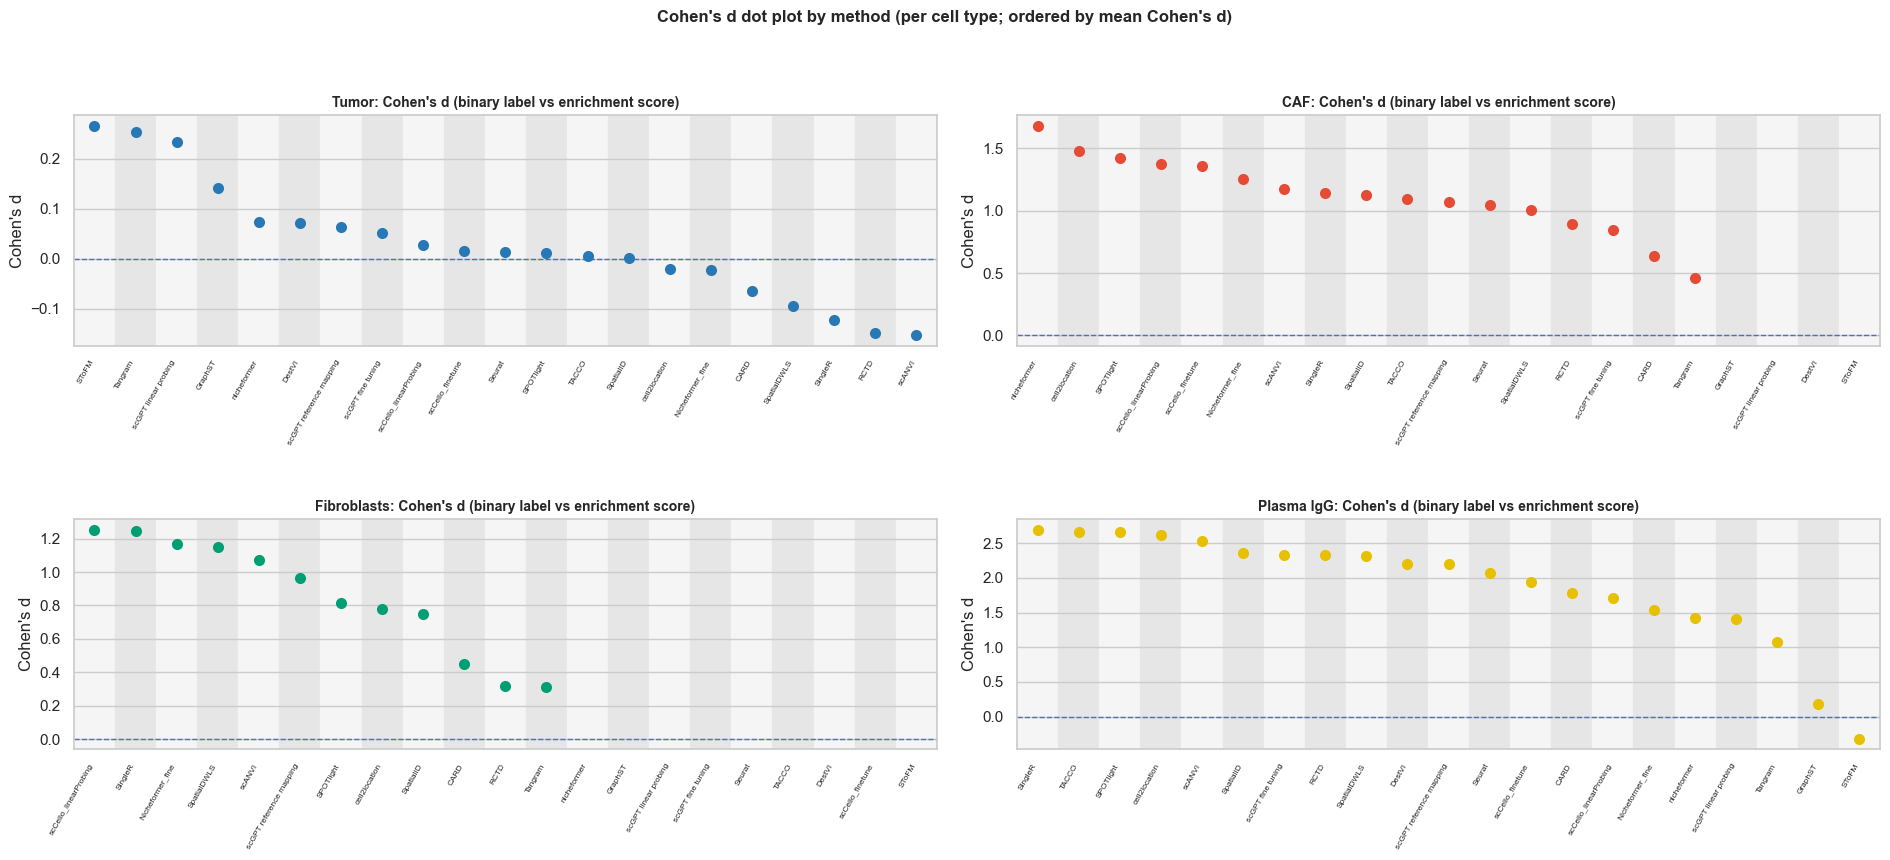

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/HumanLymph/cohens_d_Supplemental2.pdf
Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/HumanLymph/cohens_d_Supplemental2.svg


In [11]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["text.usetex"] = False
mpl.rcParams["pdf.use14corefonts"] = False
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "Arial"

corr_df = auc_df

CELL_PANELS = [
    ("Tumor", "Tumor", "#2878B5"),
    ("CAF", "CAF", "#E64B35"),
    ("Fibroblasts", "Fibroblasts", "#009E73"),
    ("Plasma IgG", "Plasma_IgG", "#E7C000"),
]

sns.set(style="whitegrid")

n_m = max(
    12,
    int(corr_df.loc[corr_df["note"] == "ok", "method"].nunique()),
)
fig_w = max(14.0, n_m * 0.45 * 2)
fig, axes = plt.subplots(2, 2, figsize=(fig_w, 8.5))
axes = axes.ravel()

for ax, (disp_name, ct_key, panel_color) in zip(axes, CELL_PANELS):
    pearson_df = corr_df[
        (corr_df["note"] == "ok")
        & (corr_df["cell_type"].astype(str) == ct_key)
    ].copy()
    pearson_df["cohens_d"] = pd.to_numeric(pearson_df["cohens_d"], errors="coerce")
    pearson_df = pearson_df.dropna(subset=["cohens_d", "method"])

    if pearson_df.empty:
        ax.text(
            0.5,
            0.5,
            f"No ok data for {disp_name}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(disp_name, fontweight="bold")
        continue

    method_rank = (
        pearson_df.groupby("method", as_index=False)["cohens_d"]
        .mean()
        .sort_values("cohens_d", ascending=False)
    )
    final_order = method_rank["method"].tolist()

    pearson_plot = pearson_df[
        pearson_df["method"].astype(str).isin(final_order)
    ].copy()
    pearson_plot["method"] = pd.Categorical(
        pearson_plot["method"], categories=final_order, ordered=True
    )

    for i, _m in enumerate(final_order):
        bg = "0.96" if i % 2 == 0 else "0.90"
        ax.axvspan(i - 0.5, i + 0.5, color=bg, zorder=0)

    sns.stripplot(
        data=pearson_plot,
        x="method",
        y="cohens_d",
        order=final_order,
        color=panel_color,
        jitter=0.08,
        size=8,
        ax=ax,
        zorder=3,
    )
    sns.pointplot(
        data=method_rank[method_rank["method"].isin(final_order)],
        x="method",
        y="cohens_d",
        order=final_order,
        errorbar=None,
        join=False,
        markers="o",
        color=panel_color,
        scale=0.85,
        ax=ax,
    )
    ax.axhline(0, linestyle="--", linewidth=1, zorder=2)
    ax.set_ylabel("Cohen's d")
    ax.set_xlabel("")
    ax.set_title(
        f"{disp_name}: Cohen's d (binary label vs enrichment score)",
        fontsize=10,
        fontweight="bold",
    )
    ax.set_xticks(np.arange(len(final_order)))
    ax.set_xticklabels(final_order, rotation=60, ha="right", fontsize=6)

plt.suptitle(
    "Cohen's d dot plot by method (per cell type; ordered by mean Cohen's d)",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout(h_pad=3.2, w_pad=1.0, pad=0.6, rect=[0, 0.02, 1, 0.96])

out_dir = "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/HumanLymph"
out_pdf = f"{out_dir}/cohens_d_Supplemental2.pdf"
out_svg = f"{out_dir}/cohens_d_Supplemental2.svg"
os.makedirs(out_dir, exist_ok=True)
plt.savefig(out_pdf, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")
print(f"Saved: {out_svg}")
